# Autoencoder Compression Quality Diagnostics

Visualisation notebook for the `DenoisingAutoencoder` — analogous to `visualise_rom.ipynb`.

**Contents:**
1. Load trained autoencoder & dataset
2. Original waveform vs reconstruction (from noisy data)
3. Distribution of relative errors with summary statistics
4. Eigenvalues of the covariance matrix (data, waveform, bottleneck)
5. Distance-vs-distance scatter plots
6. Sensitivity to single-parameter variation (fix one, vary the other)

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import h5py

from pembhb import ROOT_DIR
from pembhb.data import MBHBDataModule
from pembhb.autoencoder import DenoisingAutoencoder

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

## 1 — Configuration & loading

In [28]:
# ── paths ─────────────────────────────────────────────────────────────────
# Point these to your trained checkpoint and the dataset it was trained on.
import glob


ckpt_path = glob.glob("/data/gpuleo/mbhb/logs/autoencoder/version_12/checkpoints/*.ckpt")[0]  # <-- fill in: path to the .ckpt file
#data_filename = "/data/gpuleo/mbhb/20260212fullsky_narrowmc_tc_v0/simulation_round_1.h5"
data_filename = "/data/gpuleo/mbhb/20260202_narrowprior_v1/simulation_round_0.h5"
# Datasets where one parameter is fixed and the other varies
fix_q_filename  = "miao"
fix_mc_filename = "bau"

# Output directory for plots
ae_basename = os.path.basename(ckpt_path).removesuffix('.ckpt')
plot_dir = os.path.join(ROOT_DIR, "plots", f"diagnose_ae_{ae_basename}")
os.makedirs(plot_dir, exist_ok=True)
print(f"Plots → {plot_dir}")

Plots → /u/g/gpuleo/pembhb/plots/diagnose_ae_ae-epoch=261-val_loss=5.7389e-09


In [29]:
# ── load autoencoder from checkpoint ──────────────────────────────────────
ae = DenoisingAutoencoder.load_from_checkpoint(ckpt_path, map_location=device)
ae = ae.to(device)
ae.eval()
print(f"Loaded autoencoder  representation={ae.representation}  "
      f"n_channels={ae.n_channels}  n_freqs={ae.n_freqs}  ")
print(f"Normalisation fitted: global_scale={ae.global_scale_factor.item():.4e}")

[AutoEncoder] High-freq only mode: reconstructing bins [2048:4096] (2048 bins)
Loaded autoencoder  representation=real_imag  n_channels=2  n_freqs=4096  
Normalisation fitted: global_scale=1.3464e-17


In [ ]:
# ── load data ─────────────────────────────────────────────────────────────
batch_size = 400
datamodule = MBHBDataModule(data_filename, batch_size=batch_size,
                            num_workers=2, cache_in_memory=False)
datamodule.setup(stage="fit")
dataloader = datamodule.train_dataloader(shuffle=False)

with h5py.File(data_filename, 'r') as f:
    freqs = f["frequencies"][()]
print(f"Dataset loaded: {len(datamodule.full_dataset)} samples, {len(freqs)} freq bins")

Dataset loaded: 50000 samples, 4096 freq bins


## 2 — Run autoencoder on data: collect reconstructions & bottlenecks

In [31]:
# Collect reconstructions, bottlenecks, originals over several batches
N_batches_eval = 5  # how many batches to evaluate

all_wave_fd = []
all_data_fd = []
all_rec_norm = []      # reconstructed (normalised space)
all_clean_norm = []    # clean target (normalised space)
all_bottleneck = []    # flattened bottleneck
all_params = []

with torch.no_grad():
    for ii, batch in enumerate(dataloader):
        if ii >= N_batches_eval:
            break
        wave_fd = batch["wave_fd"].to(device)
        noise_fd = batch["noise_fd"].to(device)
        data_fd = wave_fd + noise_fd
        params = batch["source_parameters"][:, :2]  # (B, 2): logMc, q

        # Preprocess (complex → real → normalise)
        noisy_norm = ae.preprocess(data_fd)
        clean_norm = ae.preprocess(wave_fd)

        # Encode → bottleneck
        bottleneck = ae.encode(noisy_norm)
        print(bottleneck.shape)
        
        # Decode → reconstruction in normalised space
        rec_norm = ae.decode(bottleneck)

        all_wave_fd.append(wave_fd.cpu())
        all_data_fd.append(data_fd.cpu())
        all_rec_norm.append(rec_norm.cpu())
        all_clean_norm.append(clean_norm.cpu())
        all_bottleneck.append(bottleneck.reshape(bottleneck.shape[0], -1).cpu())
        all_params.append(params.cpu())


wave_fd     = torch.cat(all_wave_fd)
data_fd     = torch.cat(all_data_fd)
rec_norm    = torch.cat(all_rec_norm)
clean_norm  = torch.cat(all_clean_norm)
bottleneck  = torch.cat(all_bottleneck)
params      = torch.cat(all_params)

# Denormalise reconstruction back to the real representation space
rec_real   = ae._denormalize(rec_norm.to(device)).cpu()
clean_real = ae._denormalize(clean_norm.to(device)).cpu()

# Handle high_freq_only: slice clean to match reconstruction dimensions
if ae.high_freq_only:
    clean_norm_target  = clean_norm[:, :, ae.freq_split_idx:]
    clean_real_target  = clean_real[:, :, ae.freq_split_idx:]
    freqs_target       = freqs[ae.freq_split_idx:]
else:
    clean_norm_target  = clean_norm
    clean_real_target  = clean_real
    freqs_target       = freqs

n_samples = wave_fd.shape[0]
n_ch = ae.n_channels
print(f"Evaluated {n_samples} samples")
print(f"Bottleneck shape concatenated : {bottleneck.shape} features")
print(f"Reconstruction shape: {rec_norm.shape}  (target freqs: {len(freqs_target)})")

torch.Size([400, 128])
torch.Size([400, 128])
torch.Size([400, 128])
torch.Size([400, 128])
torch.Size([400, 128])
Evaluated 2000 samples
Bottleneck shape concatenated : torch.Size([2000, 128]) features
Reconstruction shape: torch.Size([2000, 4, 2048])  (target freqs: 2048)


In [20]:
# Convert clean_real_target and rec_real back to complex format
# Shape: (N, 2*n_ch, n_freqs) -> (N, n_ch, n_freqs) complex
# Channel ordering: [re_ch0, im_ch0, re_ch1, im_ch1, ...]

clean_complex_target = clean_real_target[:, 0::2, :] + 1j * clean_real_target[:, 1::2, :]
rec_complex_target = rec_real[:, 0::2, :] + 1j * rec_real[:, 1::2, :]

print(f"clean_complex_target shape: {clean_complex_target.shape}")  # (N, n_ch, n_freqs_target)
print(f"rec_complex_target shape:   {rec_complex_target.shape}")

amp_clean_target = torch.abs(clean_complex_target)
amp_rec_target = torch.abs(rec_complex_target)

clean_complex_target shape: torch.Size([2000, 2, 2048])
rec_complex_target shape:   torch.Size([2000, 2, 2048])


## 3 — Original waveform vs reconstruction

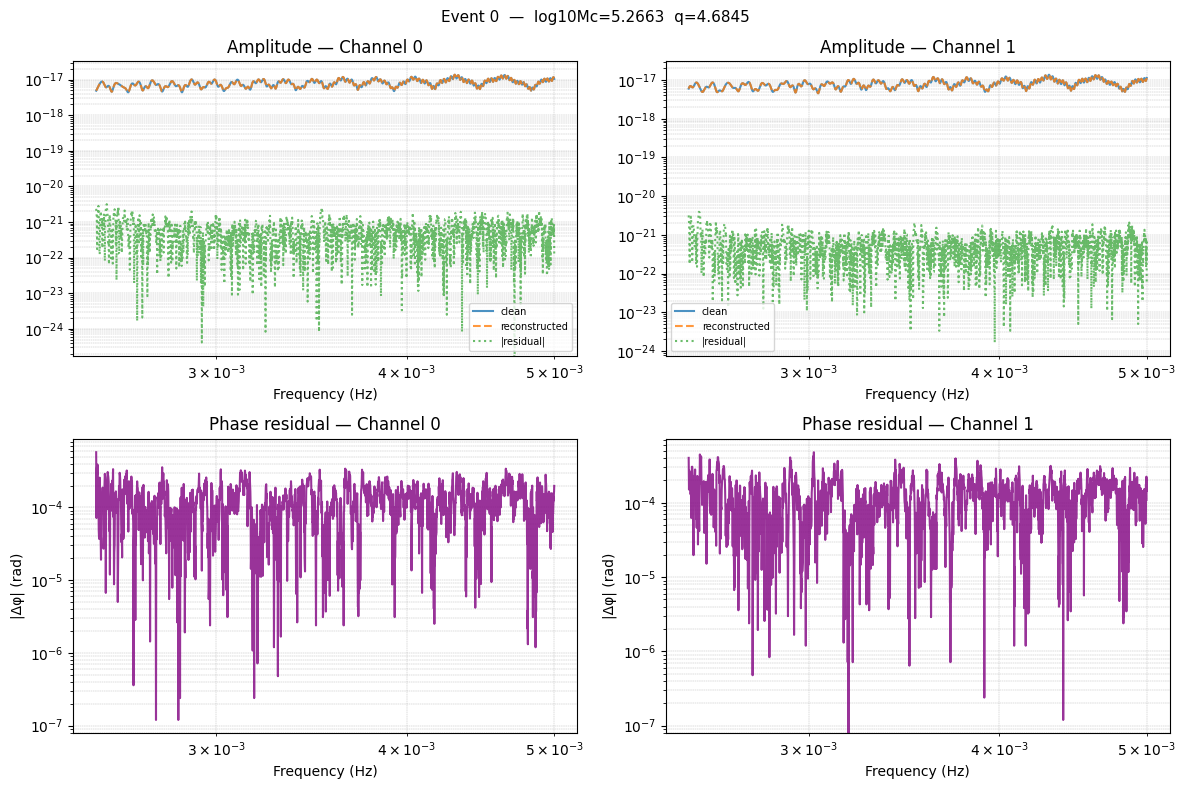

In [21]:
N_events_plot = 1

# We compare in the *complex amplitude and phase* space
# Use *_target variants so shapes match when high_freq_only is enabled.
for j in range(N_events_plot):
    fig, axes = plt.subplots(2, n_ch, figsize=(6 * n_ch, 8))
    if n_ch == 1:
        axes = axes.reshape(2, 1)

    for c in range(n_ch):
        # --- Amplitude ---
        ax = axes[0, c]
        orig_amp = amp_clean_target[j, c, :].numpy()
        recon_amp = amp_rec_target[j, c, :].numpy()
        residual_amp = np.abs(orig_amp - recon_amp)

        ax.plot(freqs_target, orig_amp, label="clean", alpha=0.8)
        ax.plot(freqs_target, recon_amp, '--', label="reconstructed", alpha=0.8)
        ax.plot(freqs_target, residual_amp, ':', label="|residual|", alpha=0.7)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(f"Amplitude — Channel {c}")
        ax.legend(fontsize=7)
        ax.grid(True, which='both', ls='--', lw=0.3)

        # --- Phase residual ---
        ax = axes[1, c]
        phase_clean = torch.angle(clean_complex_target[j, c, :]).numpy()
        phase_rec = torch.angle(rec_complex_target[j, c, :]).numpy()
        # Wrap-safe phase difference
        phase_diff = np.abs(np.angle(np.exp(1j * (phase_clean - phase_rec))))

        ax.plot(freqs_target, phase_diff, color='purple', alpha=0.8)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylabel("|Δφ| (rad)")
        ax.set_title(f"Phase residual — Channel {c}")
        ax.grid(True, which='both', ls='--', lw=0.3)

    p = params[j].numpy()
    fig.suptitle(f"Event {j}  —  log10Mc={p[0]:.4f}  q={p[1]:.4f}", fontsize=11)
    fig.tight_layout()
    fig.savefig(os.path.join(plot_dir, f"ae_reconstruction_event_{j}.png"), dpi=150)
    plt.show()
    plt.close(fig)

In [22]:
# Also compare in the *complex* domain (amplitude)
# Reconstruct complex waveform from AE output through the full encode→decode pipeline
# (The AE works in normalised real space; here we compare amplitudes for intuition.)

amp_orig = torch.abs(wave_fd)
# Reconstruct complex waveform from the real representation output
# rec_real has shape (N, 2*n_ch, n_freqs) where real and imag are interleaved
#rec_complex = ae._real_to_complex(rec_real.to(device)).cpu()
amp_rec = torch.abs(rec_complex)
amp_data = torch.abs(data_fd)

for j in range(min(N_events_plot, n_samples)):
    fig, axes = plt.subplots(1, n_ch, figsize=(6 * n_ch, 4))
    if n_ch == 1:
        axes = [axes]
    for c in range(n_ch):
        ax = axes[c]
        ax.plot(freqs, amp_orig[j, c].numpy(), label='clean |wave_fd|', alpha=0.8)
        ax.plot(freqs, amp_data[j, c].numpy(), label='noisy |data_fd|', alpha=0.4)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'Channel {c}')
        ax.legend(fontsize=7)
        ax.grid(True, which='both', ls='--', lw=0.3)
        # Compute and plot residual (difference between noisy and clean amplitudes)
        residual_amp = torch.abs(amp_data[j, c] - amp_orig[j, c]).numpy()
        ax.plot(freqs, residual_amp, color='green', label='|residual|', alpha=0.7, linestyle=':')
    p = params[j].numpy()
    fig.suptitle(f"Event {j} (complex amplitude)  —  log10Mc={p[0]:.4f}  q={p[1]:.4f}", fontsize=11)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

NameError: name 'rec_complex' is not defined

## 4 — Distribution of relative errors

In [39]:
# Relative error between clean waveform and denoised (reconstructed) data
# Computed in the complex domain: ||denoised - clean||₂ / ||clean||₂
# rec_complex_target = AE output (denoised), clean_complex_target = clean waveform

err_flat = (rec_complex_target - clean_complex_target).reshape(n_samples, -1)
clean_flat = clean_complex_target.reshape(n_samples, -1)

abs_err = torch.linalg.norm(err_flat, dim=1).float()
clean_norms = torch.linalg.norm(clean_flat, dim=1).float()
rel_err = (abs_err / clean_norms).numpy()

mean_rel_err = float(np.mean(rel_err))
median_rel_err = float(np.median(rel_err))
std_rel_err = float(np.std(rel_err))
max_rel_err = float(np.max(rel_err))

print(f"Relative error: clean waveform vs denoised data ({n_samples} samples):")
print(f"  mean   = {mean_rel_err:.4e}")
print(f"  median = {median_rel_err:.4e}")
print(f"  std    = {std_rel_err:.4e}")
print(f"  max    = {max_rel_err:.4e}")

Relative error: clean waveform vs denoised data (2000 samples):
  mean   = 1.6545e-04
  median = 1.5640e-04
  std    = 4.2791e-05
  max    = 4.5649e-04


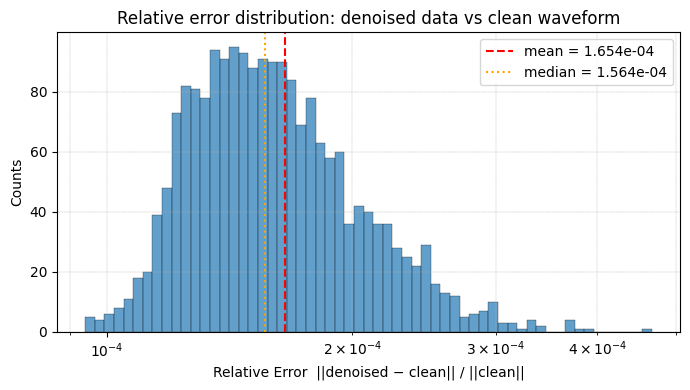

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
bins = np.logspace(np.log10(rel_err.min() + 1e-20), np.log10(rel_err.max() + 1e-5), 60)
ax.hist(rel_err, bins=bins, alpha=0.7, edgecolor='black', linewidth=0.3)
ax.axvline(mean_rel_err, color='red', linestyle='--', lw=1.5,
           label=f'mean = {mean_rel_err:.3e}')
ax.axvline(median_rel_err, color='orange', linestyle=':', lw=1.5,
           label=f'median = {median_rel_err:.3e}')
ax.set_xscale('log')
ax.set_xlabel('Relative Error  ||denoised − clean|| / ||clean||')
ax.set_ylabel('Counts')
ax.set_title('Relative error distribution: denoised data vs clean waveform')
ax.legend()
ax.grid(True, which='both', ls='--', lw=0.3)
fig.tight_layout()
fig.savefig(os.path.join(plot_dir, 'ae_relative_error_histogram.png'), dpi=200)
plt.show()
plt.close(fig)

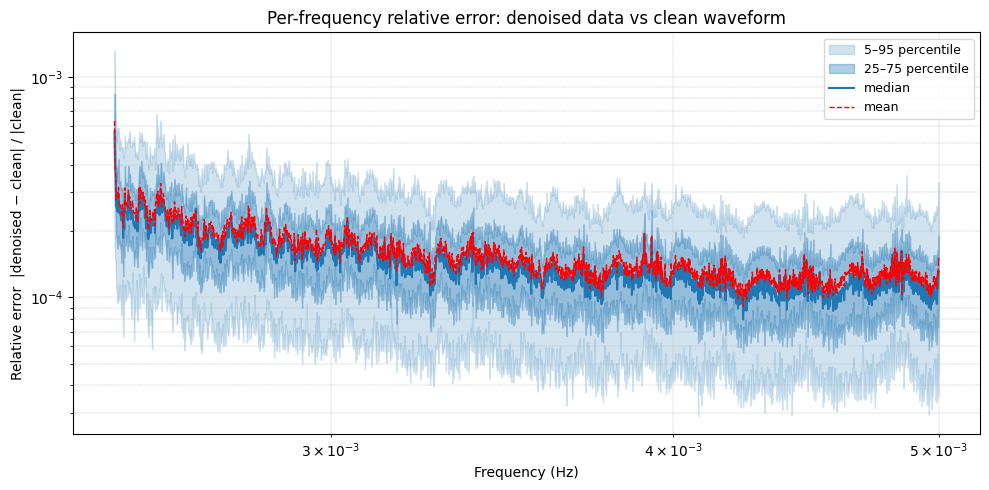

In [41]:
# Per-frequency-bin relative error using complex amplitude:
#   |denoised_complex - clean_complex| / |clean_complex|

err_complex_per_bin = torch.abs(rec_complex_target - clean_complex_target)  # (N, n_ch, n_freqs)
amp_clean_per_bin   = torch.abs(clean_complex_target)                       # (N, n_ch, n_freqs)

# Average over channels → (N, n_freqs_target), then stats over samples
abs_err_avg_ch   = err_complex_per_bin.mean(dim=1).numpy()
abs_clean_avg_ch = amp_clean_per_bin.mean(dim=1).numpy()

rel_err_per_bin = abs_err_avg_ch / (abs_clean_avg_ch + 1e-30)

# Summary statistics across samples for each frequency bin
mean_rel_per_freq   = np.mean(rel_err_per_bin, axis=0)
median_rel_per_freq = np.median(rel_err_per_bin, axis=0)
p5_rel_per_freq     = np.percentile(rel_err_per_bin, 5, axis=0)
p95_rel_per_freq    = np.percentile(rel_err_per_bin, 95, axis=0)
p25_rel_per_freq    = np.percentile(rel_err_per_bin, 25, axis=0)
p75_rel_per_freq    = np.percentile(rel_err_per_bin, 75, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.fill_between(freqs_target, p5_rel_per_freq, p95_rel_per_freq,
                alpha=0.2, color='C0', label='5–95 percentile')
ax.fill_between(freqs_target, p25_rel_per_freq, p75_rel_per_freq,
                alpha=0.35, color='C0', label='25–75 percentile')
ax.plot(freqs_target, median_rel_per_freq, color='C0', lw=1.5, label='median')
ax.plot(freqs_target, mean_rel_per_freq, color='red', lw=1, ls='--', label='mean')

ax.set_xlabel('Frequency (Hz)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('Relative error  |denoised − clean| / |clean|')
ax.set_title('Per-frequency relative error: denoised data vs clean waveform')
ax.legend(fontsize=9)
ax.grid(True, which='both', ls='--', lw=0.3)
fig.tight_layout()
fig.savefig(os.path.join(plot_dir, 'ae_relative_error_per_freq.png'), dpi=200)
plt.show()
plt.close(fig)

## 5 — Eigenvalues of covariance matrices

Compare the spectral structure of:
- **data** (noisy, `wave_fd + noise_fd`)
- **waveform** (clean, `wave_fd`)
- **bottleneck** (compressed representation)

In [42]:
def top_eigenvalues(X: torch.Tensor, label: str, max_eigs: int = 200):
    """Compute top eigenvalues of the covariance of X (N, D).
    Uses SVD on the centred data matrix for numerical stability."""
    X = X.float()
    X_c = X - X.mean(dim=0, keepdim=True)
    # If D > N use X X^T trick, otherwise X^T X
    N, D = X_c.shape
    if D > N:
        gram = X_c @ X_c.T / (N - 1)
        eigs = torch.linalg.eigvalsh(gram)
    else:
        cov = X_c.T @ X_c / (N - 1)
        eigs = torch.linalg.eigvalsh(cov)
    eigs = eigs.flip(0)[:max_eigs].numpy()
    print(f"[{label}] shape={tuple(X.shape)}, top-5 eigenvalues: {eigs[:5]}")
    return eigs

In [43]:
# Flatten to (N, D) matrices
# Use the real representation for data/waveform to match the AE's working space
data_real_flat   = ae._complex_to_real(data_fd).reshape(n_samples, -1)
wave_real_flat   = ae._complex_to_real(wave_fd).reshape(n_samples, -1)
bottleneck_flat  = bottleneck  # already (N, D_bottleneck)

eigs_data   = top_eigenvalues(data_real_flat,  "noisy data")
eigs_wave   = top_eigenvalues(wave_real_flat,  "clean waveform")
eigs_bottle = top_eigenvalues(bottleneck_flat, "bottleneck")

[noisy data] shape=(2000, 16384), top-5 eigenvalues: [4.7117533e-34 3.0607698e-36 2.5213278e-36 8.2030252e-38 7.9821923e-38]
[clean waveform] shape=(2000, 16384), top-5 eigenvalues: [4.7114360e-34 3.0440784e-36 2.5083092e-36 9.0882333e-39 8.3476709e-39]
[bottleneck] shape=(2000, 128), top-5 eigenvalues: [4.4672227e+04 1.8761961e+04 2.8771136e+02 3.7229462e+01 1.0041119e+01]


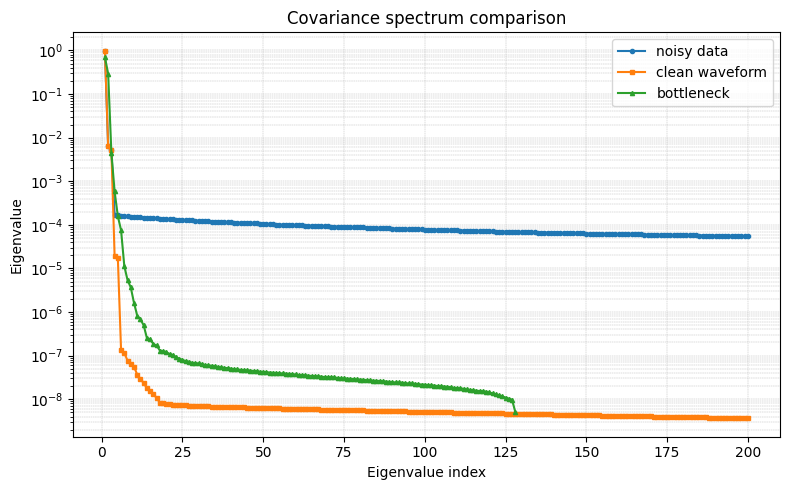

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(np.arange(1, len(eigs_data) + 1),   eigs_data/np.sum(eigs_data),   'o-', ms=3, label='noisy data')
ax.plot(np.arange(1, len(eigs_wave) + 1),    eigs_wave/np.sum(eigs_wave),   's-', ms=3, label='clean waveform')
ax.plot(np.arange(1, len(eigs_bottle) + 1),  eigs_bottle/np.sum(eigs_bottle), '^-', ms=3, label='bottleneck')

ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('Eigenvalue')
ax.set_yscale('log')
ax.set_title('Covariance spectrum comparison')
ax.legend()
ax.grid(True, which='both', ls='--', lw=0.3)
fig.tight_layout()
fig.savefig(os.path.join(plot_dir, 'ae_covariance_eigenvalues.png'), dpi=200)
plt.show()
plt.close(fig)

## 6 — Distance-vs-distance plots

1. Distance in bottleneck space  vs  distance between original waveforms
2. Distance between reconstructed waveforms  vs  distance between original waveforms

In [25]:
# Sub-sample to avoid huge distance matrices
N_dist = min(400, n_samples)

# Flatten representations
# Use clean_real_target for the waveform so its frequency range matches rec_real
wave_target_flat = clean_real_target[:N_dist].reshape(N_dist, -1)
rec_flat  = rec_real[:N_dist].reshape(N_dist, -1)  # reconstruction (denormalised real repr)
bn_flat   = bottleneck[:N_dist]              # bottleneck
par_sub   = params[:N_dist]

def pairwise_dist(X):
    """Upper-triangular pairwise Euclidean distances."""
    diff = X.unsqueeze(1) - X.unsqueeze(0)
    D = torch.sqrt((diff ** 2).sum(dim=-1))
    mask = torch.triu(torch.ones(D.shape[0], D.shape[0], dtype=bool), diagonal=1)
    return D[mask].numpy()

d_wave = pairwise_dist(wave_target_flat)
d_rec  = pairwise_dist(rec_flat)
d_bn   = pairwise_dist(bn_flat)
d_par  = pairwise_dist(par_sub)

print(f"Number of pairwise distances: {len(d_wave)}")

Number of pairwise distances: 79800


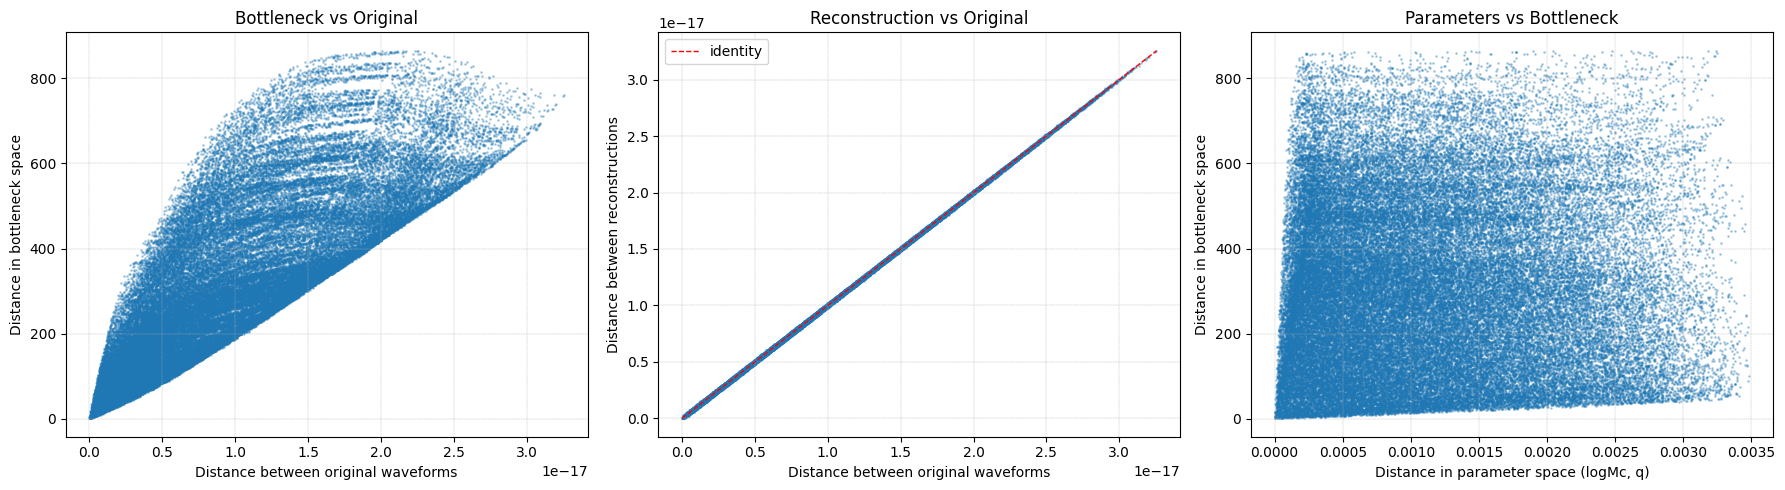

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) bottleneck dist vs waveform dist
ax = axes[0]
ax.scatter(d_wave, d_bn, s=1, alpha=0.3)
ax.set_xlabel('Distance between original waveforms')
ax.set_ylabel('Distance in bottleneck space')
ax.set_title('Bottleneck vs Original')
ax.grid(True, ls='--', lw=0.3)

# (2) reconstruction dist vs waveform dist
ax = axes[1]
ax.scatter(d_wave, d_rec, s=1, alpha=0.3)
lim = max(d_wave.max(), d_rec.max())
ax.plot([0, lim], [0, lim], 'r--', lw=1, label='identity')
ax.set_xlabel('Distance between original waveforms')
ax.set_ylabel('Distance between reconstructions')
ax.set_title('Reconstruction vs Original')
ax.legend()
ax.grid(True, ls='--', lw=0.3)

# (3) parameter dist vs bottleneck dist
ax = axes[2]
ax.scatter(d_par, d_bn, s=1, alpha=0.3)
ax.set_xlabel('Distance in parameter space (logMc, q)')
ax.set_ylabel('Distance in bottleneck space')
ax.set_title('Parameters vs Bottleneck')
ax.grid(True, ls='--', lw=0.3)

fig.tight_layout()
fig.savefig(os.path.join(plot_dir, 'ae_distance_comparison.png'), dpi=200)
plt.show()
plt.close(fig)

In [32]:
fix_q_filename = "/data/gpuleo/mbhb/fix_q_vary_mc_2x.h5"
fix_mc_filename = "/data/gpuleo/mbhb/fix_mc_vary_q_2x.h5"

## 7 — Sensitivity to single-parameter variation

Load datasets where one parameter is fixed and the other varies.  
For each, compute the relative distance to a fiducial waveform (middle of the prior)  
and overlay the mean reconstruction relative error as a horizontal reference line.

In [ ]:
def load_variation_dataset(filename, ae_model, batch_size=100):
    """Load a fix-one-vary-other dataset and return waveforms, params,
    bottlenecks, reconstructions (normalised), and clean waveforms (normalised)."""
    dm = MBHBDataModule(filename, batch_size=batch_size,
                        num_workers=2, cache_in_memory=False)
    dm.setup(stage="test")
    dl = dm.test_dataloader()

    waves, datas, bns, pars, recs_norm, cleans_norm = [], [], [], [], [], []
    with torch.no_grad():
        for batch in dl:
            w = batch["wave_fd"].to(device)
            n = batch["noise_fd"].to(device)
            d = w + n
            p = batch["source_parameters"][:, :2].cpu()

            noisy_norm = ae_model.preprocess(d)
            clean_norm = ae_model.preprocess(w)
            bn = ae_model.encode(noisy_norm)
            rec_norm = ae_model.decode(bn)

            waves.append(w.cpu())
            datas.append(d.cpu())
            bns.append(bn.reshape(bn.shape[0], -1).cpu())
            pars.append(p)
            recs_norm.append(rec_norm.cpu())
            cleans_norm.append(clean_norm.cpu())

    return (torch.cat(waves), torch.cat(datas),
            torch.cat(bns), torch.cat(pars),
            torch.cat(recs_norm), torch.cat(cleans_norm))

wave_fixq, data_fixq, bn_fixq, params_fixq, rec_norm_fixq, clean_norm_fixq = \
    load_variation_dataset(fix_q_filename, ae)
wave_fixmc, data_fixmc, bn_fixmc, params_fixmc, rec_norm_fixmc, clean_norm_fixmc = \
    load_variation_dataset(fix_mc_filename, ae)

print(f"fix-q  dataset: {wave_fixq.shape[0]} samples")
print(f"fix-mc dataset: {wave_fixmc.shape[0]} samples")

fix-q  dataset: 100 samples
fix-mc dataset: 100 samples


In [45]:
# Compute per-sample relative error: ||denoised − clean|| / ||clean||
# Handle high_freq_only: slice clean to match reconstruction frequency range
if ae.high_freq_only:
    clean_norm_fixq_target  = clean_norm_fixq[:, :, ae.freq_split_idx:]
    clean_norm_fixmc_target = clean_norm_fixmc[:, :, ae.freq_split_idx:]
else:
    clean_norm_fixq_target  = clean_norm_fixq
    clean_norm_fixmc_target = clean_norm_fixmc

def per_sample_rel_err(rec, clean):
    """Per-sample relative L2 error: ||rec - clean||₂ / ||clean||₂."""
    residual   = (rec - clean).reshape(rec.shape[0], -1)
    clean_flat = clean.reshape(clean.shape[0], -1)
    return (torch.linalg.norm(residual, dim=1) / torch.linalg.norm(clean_flat, dim=1)).numpy()

relerr_fixq  = per_sample_rel_err(rec_norm_fixq,  clean_norm_fixq_target)
relerr_fixmc = per_sample_rel_err(rec_norm_fixmc, clean_norm_fixmc_target)

sort_fixq  = torch.argsort(params_fixq[:, 0])
sort_fixmc = torch.argsort(params_fixmc[:, 1])

print(f"fix-q  mean relative error: {relerr_fixq.mean():.4e}")
print(f"fix-mc mean relative error: {relerr_fixmc.mean():.4e}")

fix-q  mean relative error: 2.4471e+00
fix-mc mean relative error: 6.1759e+00


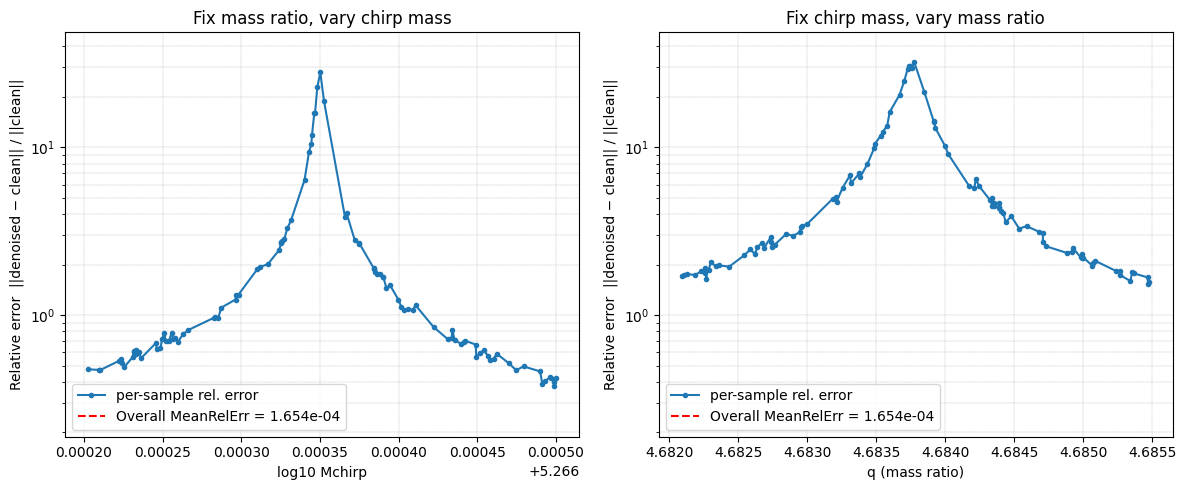

In [46]:
shared_ylim = (min(relerr_fixq.min(), relerr_fixmc.min()) * 0.5,
               max(relerr_fixq.max(), relerr_fixmc.max()) * 1.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fix q, vary chirp mass
ax = axes[0]
ax.plot(params_fixq[sort_fixq, 0].numpy(), relerr_fixq[sort_fixq], 'o-', ms=3,
        label='per-sample rel. error')
ax.axhline(mean_rel_err, color='r', linestyle='--', lw=1.5,
           label=f'Overall MeanRelErr = {mean_rel_err:.3e}')
ax.set_xlabel('log10 Mchirp')
ax.set_ylabel('Relative error  ||denoised − clean|| / ||clean||')
ax.set_title('Fix mass ratio, vary chirp mass')
ax.set_yscale('log')
ax.set_ylim(shared_ylim)
ax.legend()
ax.grid(True, which='both', ls='--', lw=0.3)

# Fix chirp mass, vary q
ax = axes[1]
ax.plot(params_fixmc[sort_fixmc, 1].numpy(), relerr_fixmc[sort_fixmc], 'o-', ms=3,
        label='per-sample rel. error')
ax.axhline(mean_rel_err, color='r', linestyle='--', lw=1.5,
           label=f'Overall MeanRelErr = {mean_rel_err:.3e}')
ax.set_xlabel('q (mass ratio)')
ax.set_ylabel('Relative error  ||denoised − clean|| / ||clean||')
ax.set_title('Fix chirp mass, vary mass ratio')
ax.set_yscale('log')
ax.set_ylim(shared_ylim)
ax.legend()
ax.grid(True, which='both', ls='--', lw=0.3)

fig.tight_layout()
fig.savefig(os.path.join(plot_dir, 'ae_sensitivity_rel_error.png'), dpi=200)
plt.show()
plt.close(fig)

In [ ]:
print("Done — all plots saved to:", plot_dir)